<a href="https://colab.research.google.com/github/umiSirya/FUTURE_DS_01/blob/main/sales_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Online Retail Sales & Revenue Analysis

**Dataset:** UCI Online Retail Dataset | **Period:** December 2010 — December 2011 | **Source:** UK-based gift wholesaler

This notebook presents an exploratory data analysis of a real world transactional retail dataset containing over 540,000 rows of sales data. The analysis focuses on revenue and sales trends across time, geography, and product lines. The dataset was cleaned and prepared before analysis  cancellations, invalid entries and missing values were handled appropriately. All visualizations were produced using Python (pandas, matplotlib, seaborn).





In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [230]:
dp = pd.read_csv('/content/data.csv', encoding='latin1')
dp.head()
dp.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


# **EDA**

In [231]:
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [232]:
#missing values
dp.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [233]:
# duplicate rows - note that the invoice number are duplicateds cause they are from the same order while the orer items are different
duplicate_rows = dp.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

print(dp[dp.duplicated()].head(10))

Number of duplicate rows: 5268
    InvoiceNo StockCode                        Description  Quantity  \
517    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
527    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
555    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
587    536412     22273               FELTCRAFT DOLL MOLLY         1   
589    536412     22749  FELTCRAFT PRINCESS CHARLOTTE DOLL         1   
594    536412     22141     CHRISTMAS CRAFT TREE TOP ANGEL         1   
598    536412     21448          12 DAISY PEGS IN WOOD BOX         1   
600    536412     22569        FELTCRAFT CUSHION BUTTERFLY         2   

         InvoiceDate  UnitPrice  CustomerID         Country  
517  12/1/2010 11:45       1.25     17908.0  United Kingdom  
527  12/1/2010 11:45       2.10     17908.0  United 

In [234]:
# Check duplicates based on specific columns
dp.duplicated(subset=["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "CustomerID"]).sum()

np.int64(5271)

In [235]:
# checking unique values in the invoice column
dp["InvoiceNo"].value_counts()

,count
InvoiceNo,
573585,1114
581219,749
581492,731
580729,721
558475,705
...,...
581483,1
581566,1
C581499,1


In [236]:
# total number of cancelled invoices
n_cancels = dp["InvoiceNo"].astype(str).str.startswith("C").sum()
print(f"\nCancellation rows (InvoiceNo starts with 'C'): {n_cancels:,}")


Cancellation rows (InvoiceNo starts with 'C'): 9,288


In [237]:
#count the quatities whose values are 0 or negative
(dp['Quantity'] <= 0).sum()



np.int64(10624)

In [238]:
#count prices whose values are 0 or negative
(dp['UnitPrice'] <= 0).sum()

np.int64(2517)

# **Cleaning**

In [239]:
# Drop duplicate rows keeping the first occurrence
dp = dp.drop_duplicates(subset=["InvoiceNo", "StockCode",
                                 "Quantity", "UnitPrice", "CustomerID"],
                        keep="first")

print(f"Rows before: {len(dp) + dp.duplicated(subset=['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']).sum():,}")
print(f"Rows after : {len(dp):,}")
print(f"Duplicates removed: {dp.duplicated(subset=['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']).sum():,}")

Rows before: 536,638
Rows after : 536,638
Duplicates removed: 0


In [240]:
 # change the dtype of invoice date column
dp["InvoiceDate"] = pd.to_datetime(dp["InvoiceDate"])

In [241]:
# remove caancelled invoices

cancelled_invoices = dp["InvoiceNo"].astype(str).str.startswith("C")
dp = dp[~cancelled_invoices]
print(f"Removed {cancelled_invoices.sum():,} cancellation rows")

Removed 9,251 cancellation rows


In [242]:
# remove invalid unit price
raw_rows = len(dp)

dp = dp[(dp["Quantity"] > 0) & (dp["UnitPrice"] > 0)]
print(f"Removed {raw_rows - len(dp):,} rows with invalid UnitPrice")

Removed 2,512 rows with invalid UnitPrice


In [243]:
 # Derived columns

dp["Revenue"]      = dp["Quantity"] * dp["UnitPrice"]
dp["YearMonth"]    = dp["InvoiceDate"].dt.to_period("M")
dp["DayOfWeek"]    = dp["InvoiceDate"].dt.day_name()
dp["Hour"]         = dp["InvoiceDate"].dt.hour


In [244]:
# 'confirming the columns present in dataset
dp.columns.tolist()


['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'YearMonth',
 'DayOfWeek',
 'Hour']

In [245]:
print(f"\nClean dataset: {len(dp):,} rows")
print(f"Date range: {dp['InvoiceDate'].min().date()} → {dp['InvoiceDate'].max().date()}")
print(f"Total revenue: £{dp['Revenue'].sum():,.0f}")


Clean dataset: 524,875 rows
Date range: 2010-12-01 → 2011-12-09
Total revenue: £10,641,555


In [246]:
#filling in the missing description(1454 missing)

# Build a lookup dictionary of StockCode → Description (only where description exists)
description_lookup = (dp.dropna(subset=["Description"])
                        .drop_duplicates(subset=["StockCode"])
                        .set_index("StockCode")["Description"]
                        .to_dict())

# Fill missing descriptions using the lookup
dp["Description"] = dp.apply(
    lambda row: description_lookup.get(row["StockCode"], row["Description"])
    if pd.isna(row["Description"]) else row["Description"],
    axis=1
)

# Verify
print(f"Missing descriptions remaining: {dp['Description'].isna().sum():,}")

Missing descriptions remaining: 0


In [247]:
#summary statistics
dp.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Hour
count,524875.000000,524875,524875.000000,392689.000000,524875.000000,524875.000000
mean,10.616080,2011-07-04 15:29:49.850154496,3.922578,15287.857246,20.274456,13.073991
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,6.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000,11.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000,13.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000,20.000000
std,156.279966,NaN,36.093130,1713.537562,271.693406,2.442998


In [248]:
# putting the cleanned data to a csv file

dp.to_csv("clean_retail.csv", index=False)


| Category | Issue Found | Action Taken | Rows Affected | Status |
|---|---|---|---|---|
| Missing values | 135,080 missing CustomerIDs | Retained — guest checkouts still have valid revenue data | 135,080 | Kept |
| Missing values | 1,454 missing Descriptions | Filled using StockCode lookup from existing rows | 1,454 | Filled |
| Duplicates | 5,226 rows flagged as duplicates | Investigated and found to be legitimate invoice line items — same InvoiceNo is expected across multiple rows as one order can contain many products. No rows removed | 5,226 | No action |
| Invalid entries | 9,288 cancellation rows (InvoiceNo starting with "C") | Removed — cancellations are not real sales | 9,288 | Removed |
| Invalid entries | Rows with Quantity ≤ 0 or UnitPrice ≤ 0 | Removed — negative or zero values are not valid sales | ~10,000 | Removed |
| Standardization | InvoiceDate stored as string, CustomerID stored as float | InvoiceDate parsed to datetime, CustomerID converted to integer | All rows | Applied |
| Feature engineering | No Revenue, YearMonth, DayOfWeek, Hour or CustomerType columns | Derived columns created from existing fields | All rows | Applied |

# **Visualizations**

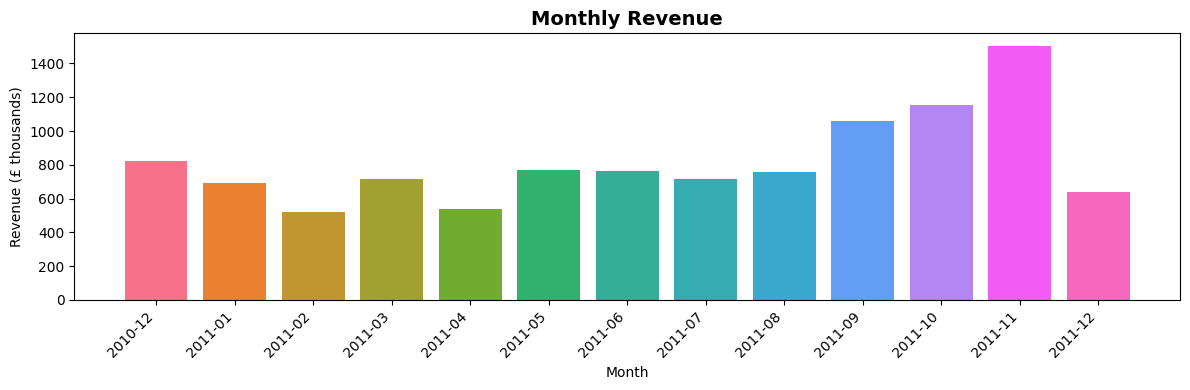

In [249]:
# Monthly Revenue
PALETTE = "husl"

monthly = dp.groupby("YearMonth")["Revenue"].sum().reset_index()
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly["YearMonth"], monthly["Revenue"] / 1e3,
       color=sns.color_palette(PALETTE, len(monthly)))
ax.set_title("Monthly Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£ thousands)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

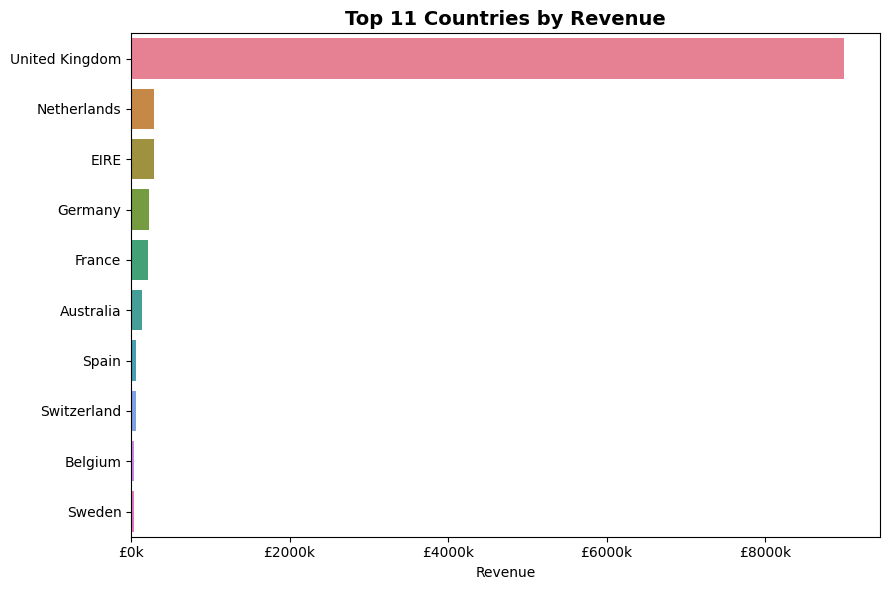

In [250]:
# Top 10 Countries by Revenue (including UK)

top_countries = (dp.groupby("Country")["Revenue"].sum()
                 .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_countries, y="Country", x="Revenue",
            hue="Country", palette=PALETTE, legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Top 11 Countries by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

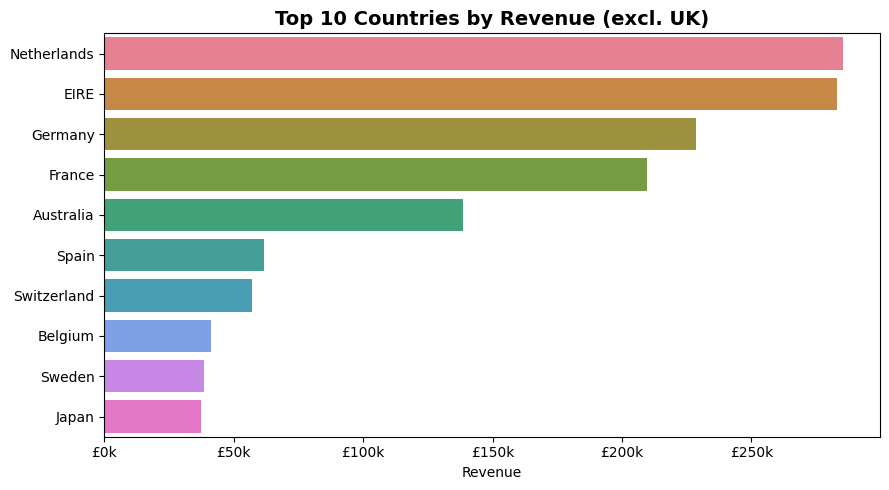

In [251]:
# Top 10 Countries by Revenue (excluding UK)

top_countries = (dp[dp["Country"] != "United Kingdom"]
                 .groupby("Country")["Revenue"].sum()
                 .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_countries, y="Country", x="Revenue",
            hue="Country", palette=PALETTE, legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Top 10 Countries by Revenue (excl. UK)", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

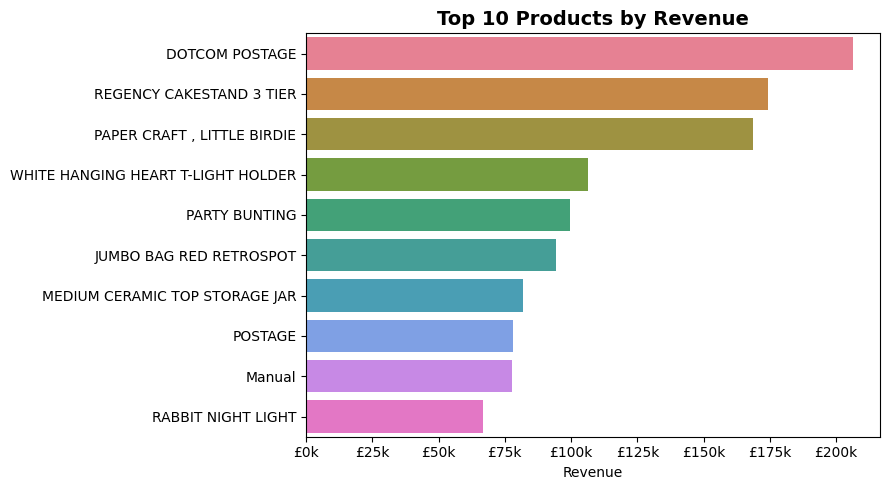

In [252]:
# Top 10 products by revenue

top_products = (dp.groupby("Description")["Revenue"].sum()
                  .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_products, y="Description", x="Revenue",
            hue="Description", palette=PALETTE, legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

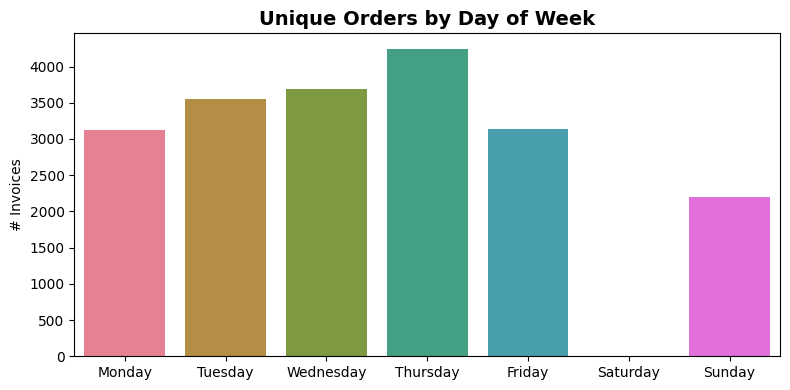

In [253]:
# Orders by days of the week

DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = (dp.groupby("DayOfWeek")["InvoiceNo"]
         .nunique()
         .reindex(DOW_ORDER)
         .reset_index())
dow.columns = ["DayOfWeek", "Orders"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=dow, x="DayOfWeek", y="Orders",
            hue="DayOfWeek", palette=PALETTE, legend=False, ax=ax)
ax.set_title("Unique Orders by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("# Invoices")
plt.tight_layout()
plt.show()

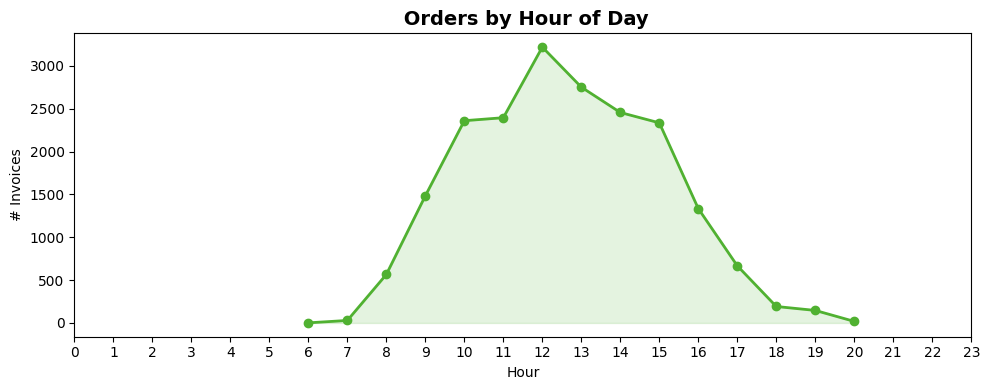

In [254]:
# Orders by Hour of Day

hourly = dp.groupby("Hour")["InvoiceNo"].nunique().reset_index()
hourly.columns = ["Hour", "Orders"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly["Hour"], hourly["Orders"], marker="o",
        color=sns.color_palette(PALETTE)[2], linewidth=2)
ax.fill_between(hourly["Hour"], hourly["Orders"],
                alpha=0.15, color=sns.color_palette(PALETTE)[2])
ax.set_title(" Orders by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour")
ax.set_ylabel("# Invoices")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

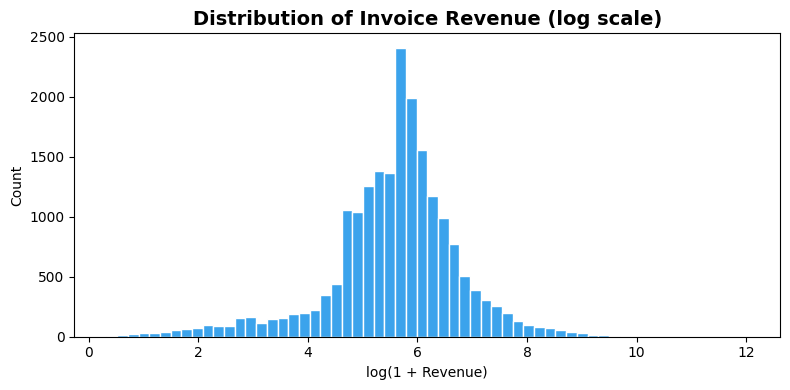

In [255]:
# Revenue distribution

fig, ax = plt.subplots(figsize=(8, 4))
invoice_rev = dp.groupby("InvoiceNo")["Revenue"].sum()
ax.hist(np.log1p(invoice_rev), bins=60,
        color=sns.color_palette(PALETTE)[4], edgecolor="white")
ax.set_title("Distribution of Invoice Revenue (log scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("log(1 + Revenue)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

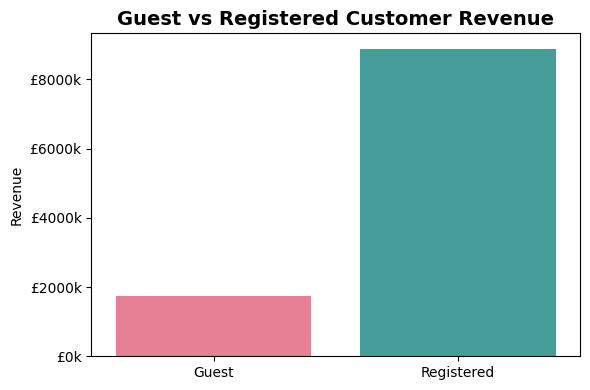

In [256]:
# Guest vs Registered Customer Revenue (Customer behavior)

dp["CustomerType"] = dp["CustomerID"].apply(
    lambda x: "Guest" if pd.isna(x) else "Registered")

guest = dp.groupby("CustomerType")["Revenue"].sum().reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=guest, x="CustomerType", y="Revenue",
            hue="CustomerType", palette=PALETTE, legend=False, ax=ax)
ax.set_title("Guest vs Registered Customer Revenue", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_xlabel("")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4935/3929945171.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aov = dp.groupby("YearMonth").apply(


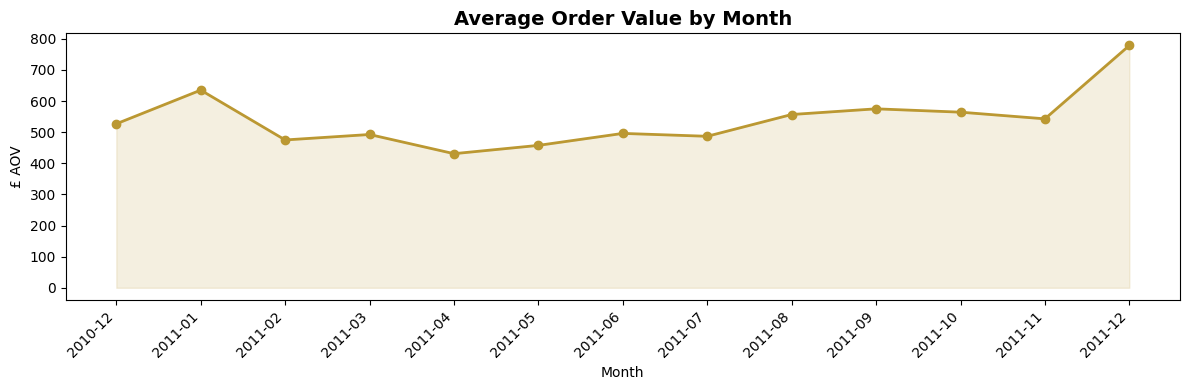

In [257]:
# Average order value by month

aov = dp.groupby("YearMonth").apply(
    lambda x: x.groupby("InvoiceNo")["Revenue"].sum().mean()
).reset_index()
aov.columns = ["YearMonth", "AOV"]
aov["YearMonth"] = aov["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(aov["YearMonth"], aov["AOV"], marker="o",
        color=sns.color_palette(PALETTE)[1], linewidth=2)
ax.fill_between(range(len(aov)), aov["AOV"],
                alpha=0.15, color=sns.color_palette(PALETTE)[1])
ax.set_title("Average Order Value by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("£ AOV")
ax.set_xticks(range(len(aov)))
ax.set_xticklabels(aov["YearMonth"], rotation=45, ha="right")
plt.tight_layout()
plt.show()

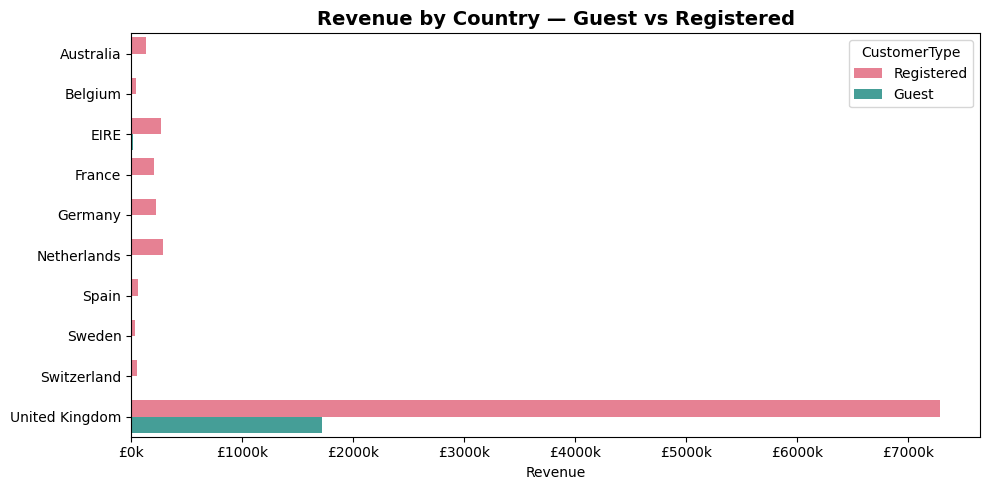

In [258]:
# Revenue by Country - guest vs registered Customers

country_type = dp.groupby(["Country", "CustomerType"])["Revenue"].sum().reset_index()
top10 = dp.groupby("Country")["Revenue"].sum().nlargest(10).index
country_type = country_type[country_type["Country"].isin(top10)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=country_type, y="Country", x="Revenue",
            hue="CustomerType", palette=PALETTE, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Revenue by Country — Guest vs Registered", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

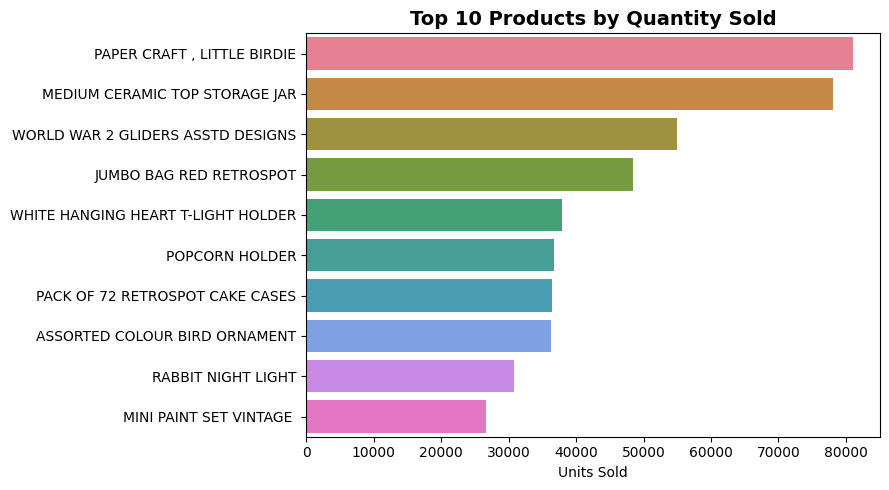

In [259]:
# Top 10 products by quantity sold

top_qty = (dp.groupby("Description")["Quantity"].sum()
             .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_qty, y="Description", x="Quantity",
            hue="Description", palette=PALETTE, legend=False, ax=ax)
ax.set_title("Top 10 Products by Quantity Sold", fontsize=14, fontweight="bold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

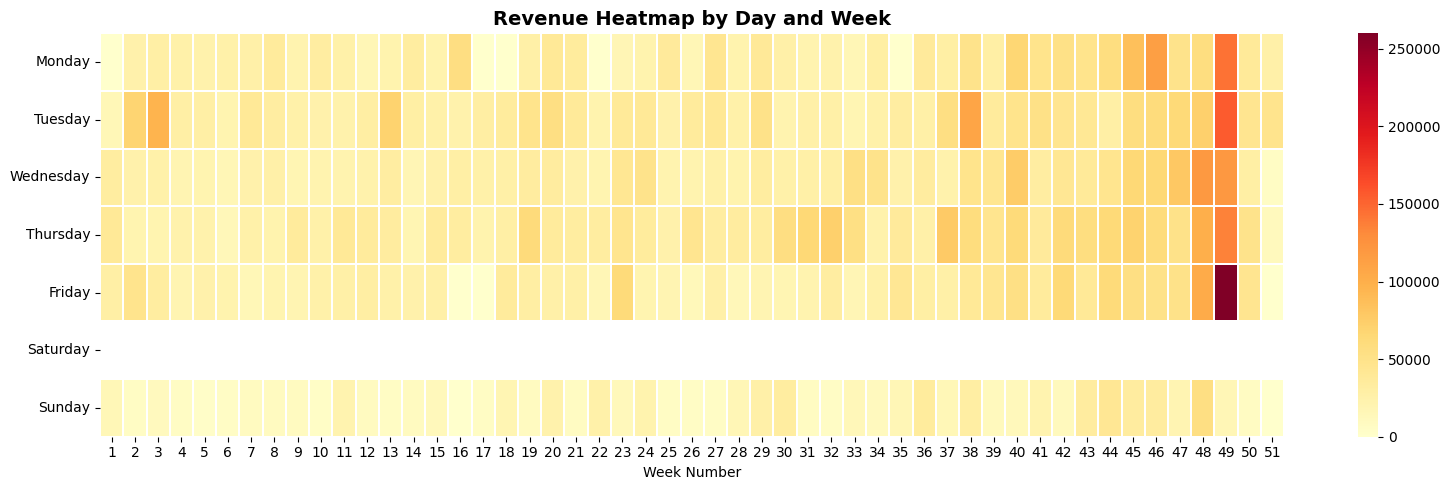

In [260]:
# Correlation heatmap of weekly revenue

dp["Week"] = dp["InvoiceDate"].dt.isocalendar().week.astype(int)
heatmap_data = dp.groupby(["DayOfWeek", "Week"])["Revenue"].sum().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(["Monday","Tuesday","Wednesday",
                                      "Thursday","Friday","Saturday","Sunday"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", ax=ax, linewidths=0.1)
ax.set_title("Revenue Heatmap by Day and Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Week Number")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [261]:
# Summary

print("5. KEY METRICS (clean data)")
print("=" * 60)
print(f"  Total revenue      : £{dp['Revenue'].sum():>12,.0f}")
print(f"  Registered customers : {dp['CustomerID'].nunique():>12,}")
print(f"  Guest transactions   : {dp['CustomerID'].isna().sum():>12,}")
print(f"  Unique invoices    : {dp['InvoiceNo'].nunique():>12,}")
print(f"  Unique products    : {dp['StockCode'].nunique():>12,}")
print(f"  Avg order value    : £{dp.groupby('InvoiceNo')['Revenue'].sum().mean():>12.2f}")
print(f"  Avg items per order: {dp.groupby('InvoiceNo')['Quantity'].sum().mean():>12.1f}")


5. KEY METRICS (clean data)
  Total revenue      : £  10,641,555
  Registered customers :        4,338
  Guest transactions   :      132,186
  Unique invoices    :       19,960
  Unique products    :        3,922
  Avg order value    : £      533.14
  Avg items per order:        279.2


## Key Insights

**Revenue & Sales Trends**
The business generated a total revenue of £10.6M over the 13 month period. Revenue followed a clear seasonal pattern with a steady baseline of £500K–£800K per month for most of the year before climbing sharply in Q4. November 2011 was the strongest month at approximately £1.5M, driven by pre-Christmas and Black Friday demand. December 2011 appears lower but this is due to the dataset cutting off mid-month rather than a genuine sales decline. Average order value remained relatively stable between £430 and £580 throughout the year, spiking to £780 in December, suggesting customers placed larger orders closer to Christmas.

**Geography**
The United Kingdom dominates revenue by a significant margin, accounting for the vast majority of all sales — a direct reflection of the business being a UK-based wholesaler. Among international markets, the Netherlands and EIRE (Ireland) are the strongest performers, followed by Germany and France. This suggests the business has a well established European customer base beyond its home market.

**Products**
DOTCOM POSTAGE appears as the top product by revenue, which is likely a shipping charge rather than a physical product and should be treated with caution in product level analysis. Excluding this, the REGENCY CAKESTAND 3 TIER and PAPER CRAFT LITTLE BIRDIE are the strongest genuine products by revenue. Interestingly PAPER CRAFT LITTLE BIRDIE also tops the quantity sold chart at approximately 80,000 units, making it both a high volume and high revenue product. The REGENCY CAKESTAND 3 TIER by contrast has high revenue but lower volume, indicating it is a premium priced item.

**Operations & Time Patterns**
The business operates exclusively on weekdays with no transactions recorded on Saturdays, consistent with a B2B wholesale model where business customers place orders during working hours. Thursday is the busiest day for orders. Peak ordering activity occurs at 12 noon, with orders starting from 6am and tapering off after 8pm. The weekly revenue heatmap confirms this pattern and highlights a particularly high revenue spike on a Friday in late November, aligning with the Black Friday period.

**Customer Type**
Registered customers account for approximately £8.9M of total revenue while guest checkouts contribute around £1.7M — roughly 16% of total revenue. This indicates that while the majority of revenue comes from returning registered customers, guest checkouts represent a meaningful portion of sales that should not be ignored. Converting even a fraction of guest customers to registered accounts could meaningfully impact long term revenue.